In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
raw_shark_df = pd.read_csv("../data/clean_data/clean_data.csv")
shark_df = raw_shark_df.drop(["type"], axis=1)

print(shark_df.head(), "\n")

nonfatal_df = shark_df[shark_df["fatal"] == "N"]
fatal_df = shark_df[shark_df["fatal"] == "Y"]

# compute overall statistics
total_attacks = len(shark_df)
total_fatal = len(fatal_df)
total_nonfatal = len(nonfatal_df)
prop_fatal = total_fatal / total_attacks

print(f"Total number of attacks: {total_attacks}")
print(f"Number of fatal attacks: {total_fatal}")
print(f"Number of nonfatal attacks: {total_nonfatal}")
print(f"Overall fatality rate: {prop_fatal:.2%}")

             country            state  activity  sex   age fatal       time  \
0            bahamas      staniel cay  swimming    m  12.0     N  afternoon   
1                usa          florida  swimming    f  17.0     N    morning   
2          australia              nsw  swimming    f  35.0     N    morning   
3  galapogos islands  santa fe island  swimming    f   NaN     N  afternoon   
4                usa          florida  swimming  NaN   NaN     N    morning   

       species  year  month  
0          NaN   NaN    6.0  
1          NaN   NaN    6.0  
2  great white   NaN    6.0  
3          NaN   NaN    6.0  
4         bull   NaN    6.0   

Total number of attacks: 5164
Number of fatal attacks: 1273
Number of nonfatal attacks: 3891
Overall fatality rate: 24.65%


In [4]:
country_counts = shark_df.groupby("country").size().to_frame(name="count").reset_index()
country_counts.sort_values(by="count", ascending=False, inplace=True)
country_counts["prop_total"] = country_counts["count"] / total_attacks
top_10_countries = country_counts.head(10)

print(f"Top 10 Countries account for {top_10_countries["prop_total"].sum()}")
top_10_countries

Top 10 Countries account for 0.7937645236250968


,country,count,prop_total
158,usa,1994,0.386135
8,australia,1084,0.209915
131,south africa,413,0.079977
113,papua new guinea,110,0.021301
9,bahamas,109,0.021108
15,brazil,100,0.019365
105,new zealand,95,0.018397
94,mexico,74,0.014330
103,new caledonia,60,0.011619
48,fiji,60,0.011619


In [5]:
filtered_df = shark_df[shark_df["country"].isin(top_10_countries["country"])]

nonfatal_df = filtered_df[filtered_df["fatal"] == "N"]
fatal_df = filtered_df[filtered_df["fatal"] == "Y"]

# compute statistics
total_attacks = len(filtered_df)
total_fatal = len(fatal_df)
total_nonfatal = len(nonfatal_df)
prop_fatal = total_fatal / total_attacks

print(f"Total number of attacks: {total_attacks}")
print(f"Number of fatal attacks: {total_fatal}")
print(f"Number of nonfatal attacks: {total_nonfatal}")
print(f"Overall fatality rate: {prop_fatal:.2%}")

Total number of attacks: 4099
Number of fatal attacks: 780
Number of nonfatal attacks: 3319
Overall fatality rate: 19.03%


In [6]:
state_counts = filtered_df["state"].value_counts().to_frame().reset_index()
top_states = state_counts[state_counts["count"] > 10]
top_states

,state,count
0,florida,987
1,new south wales,364
2,hawaii,276
3,queensland,258
4,california,215
5,western australia,172
6,kwazulu-natal,146
7,south carolina,136
8,eastern cape province,136
9,western cape province,123


In [7]:
filtered_df2 = shark_df[shark_df["state"].isin(top_states["state"])]

nonfatal_df = filtered_df2[filtered_df2["fatal"] == "N"]
fatal_df = filtered_df2[filtered_df2["fatal"] == "Y"]

# compute statistics
total_attacks = len(filtered_df2)
total_fatal = len(fatal_df)
total_nonfatal = len(nonfatal_df)
prop_fatal = total_fatal / total_attacks

print(f"Total number of attacks: {total_attacks}")
print(f"Number of fatal attacks: {total_fatal}")
print(f"Number of nonfatal attacks: {total_nonfatal}")
print(f"Overall fatality rate: {prop_fatal:.2%}")

Total number of attacks: 3702
Number of fatal attacks: 656
Number of nonfatal attacks: 3046
Overall fatality rate: 17.72%


In [8]:
filtered_df2.to_csv("../data/clean_data/topstates_data.csv", index=False)

## EDA by State

In [14]:
state_df = pd.read_csv("../data/clean_data/topstates_data.csv")

total_attacks = len(state_df)

nonfatal_df = state_df[state_df["fatal"] == "N"]
fatal_df = state_df[state_df["fatal"] == "Y"]
prop_fatal = len(fatal_df) / total_attacks

print(f"Total attacks: {total_attacks}")
print(f"Num fatal: {len(fatal_df)}")
print(f"Num nonfatal: {len(nonfatal_df)}")
print(f"Overall fatality rate: {prop_fatal:.2%}")

state_df.head()

Total attacks: 3702
Num fatal: 656
Num nonfatal: 3046
Overall fatality rate: 17.72%


,country,state,activity,sex,age,fatal,time,species,year,month
0,usa,florida,swimming,f,17.0,N,morning,NaN,NaN,6.0
1,australia,nsw,swimming,f,35.0,N,morning,great white,NaN,6.0
2,usa,florida,swimming,NaN,NaN,N,morning,bull,NaN,6.0
3,australia,western australia,dive fishing,m,35.0,Y,morning,great white,NaN,6.0
4,australia,nsw,surfing/bodyboarding,NaN,20.0,N,evening,bull,NaN,5.0


In [58]:
def fatality_rate_plots(fatal_counts_df, attribute_name: str, max_x=1400, legend_pos="lower right"):

    fig, axes = plt.subplots(1, 2, figsize=(26,8), gridspec_kw={'wspace': 0.1})

    title_word = attribute_name.capitalize()

    # bar chart for totals
    b1 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["nonfatal_count"],
        label="nonfatal"
    )
    b2 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatal_count"],
        label="fatal"
    )
    axes[0].bar_label(axes[0].containers[0], labels=fatal_counts_df["total_count"], padding=3, fontsize=6)
    axes[0].tick_params(axis="y", labelsize=6)
    axes[0].set_xlim(0, max_x)
    axes[0].legend(loc=legend_pos)


    # bar chart for death rates
    b3 = axes[1].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatality_rate"],
        color="gray"
    )
    plt.axvline(x=prop_fatal, color='red', linestyle='--', linewidth=2, label='Overall Fatality Rate')
    axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=4, fontsize=6)
    # axes[1].set_yticks([])
    axes[1].set_xlim(0, 0.8)
    axes[1].tick_params(axis="y", labelsize=6)
    axes[1].legend()


    # set labels and titles
    axes[0].set_ylabel(title_word, fontsize=13)
    axes[0].set_xlabel("Attack Count", fontsize=13)
    axes[1].set_xlabel("Fatality Rate", fontsize=13)
    fig.suptitle(f"Shark Attacks by {title_word}", fontsize=16)

    plt.savefig(f"../figures/fatrate_plots_{attribute_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

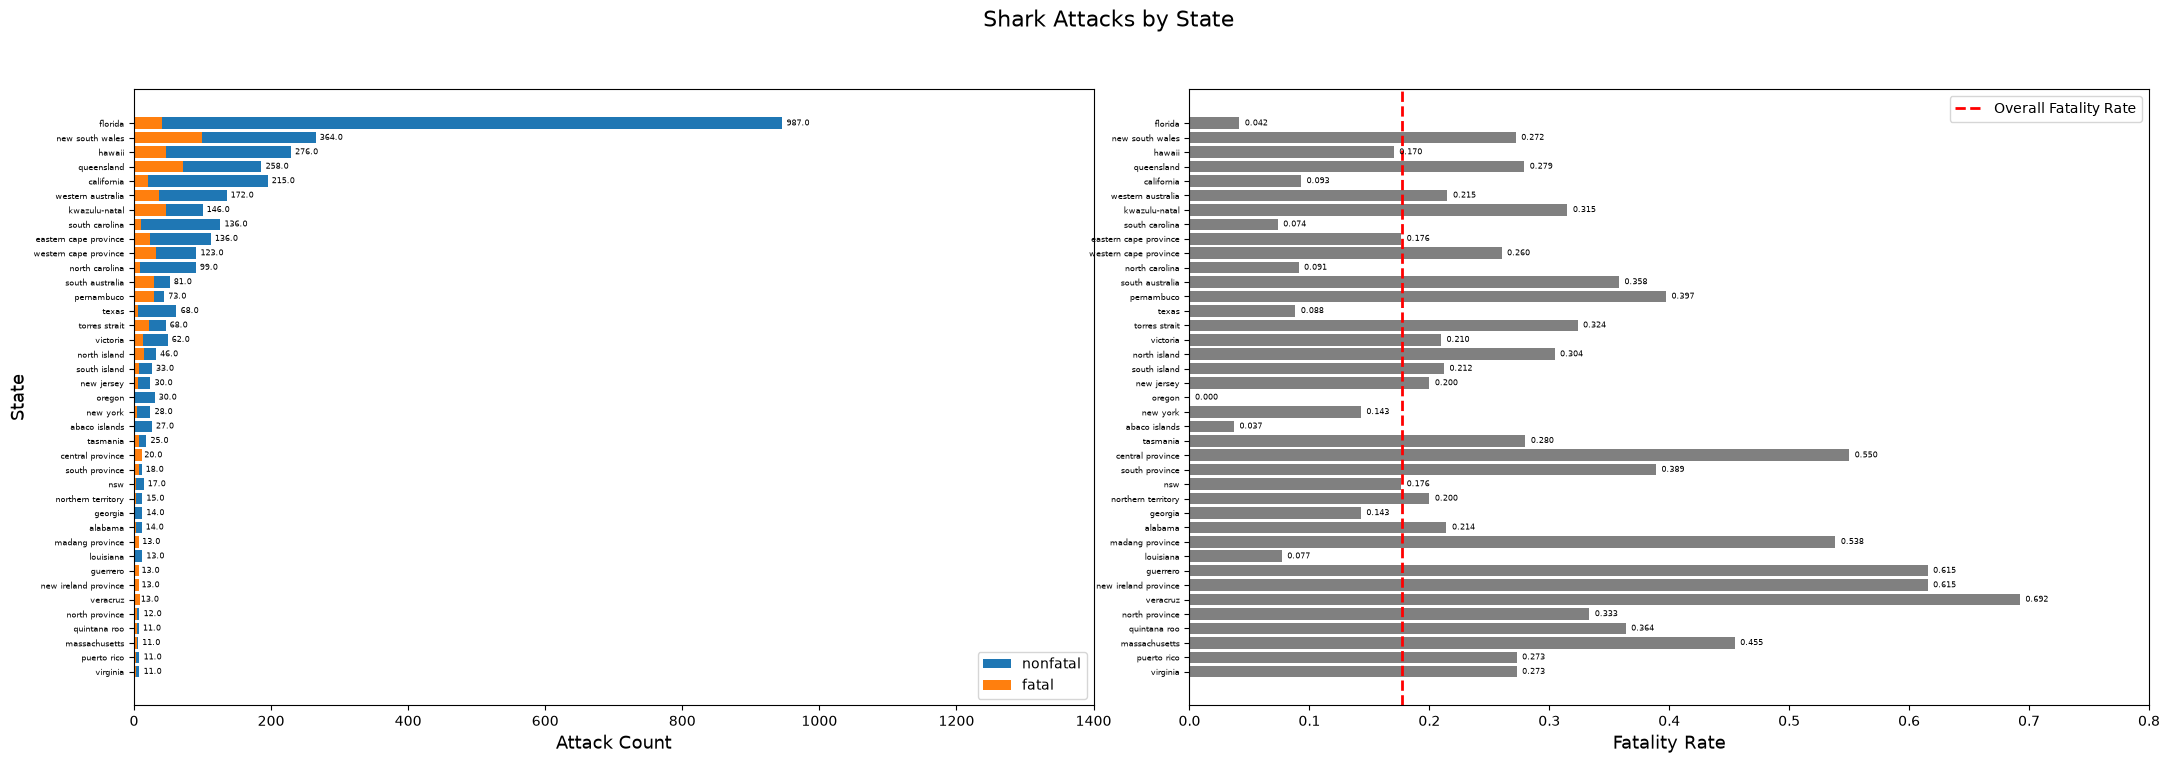

In [59]:
state_counts1 = fatal_df.groupby("state").size().to_frame(name="fatal_count").reset_index()
state_counts2 = nonfatal_df.groupby("state").size().to_frame(name="nonfatal_count").reset_index()

state_counts = state_counts2.merge(state_counts1, on="state", how="left").fillna(0)
state_counts["total_count"] = state_counts["fatal_count"] + state_counts["nonfatal_count"]
state_counts["fatality_rate"] = state_counts["fatal_count"] / state_counts["total_count"]

state_counts.sort_values("total_count", ascending=True, inplace=True)

fatality_rate_plots(state_counts, attribute_name="state")